# 07 — Statistical Models

**Étape 9 — Modèles stats (régression, Ridge/Lasso, ARIMA/SARIMA)**

Modèles économétriques/statistiques interprétables (section 10, niveaux 2-3),
à comparer aux baselines avant de passer au machine learning.


## Setup

In [9]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import data, features, models, backtest, metrics, plots

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 4)

from pathlib import Path
from sklearn.preprocessing import StandardScaler

DATA_PATH = Path("../data/processed/dataset_features.csv")

df = pd.read_csv(DATA_PATH)
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime").sort_index()

assert df.shape == (32855, 42)
assert df.index.is_unique
assert df.index.is_monotonic_increasing

SAFE_MODEL_FEATURES = [
    "price_da_lag_1d",
    "price_da_lag_2d",
    "price_da_lag_7d",
    "price_da_rollmean_1d",
    "price_da_rollstd_1d",
    "price_da_rollmean_7d",
    "price_da_rollstd_7d",
    "hour",
    "weekday",
    "is_weekend",
    "month",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "month_sin",
    "month_cos",
    "is_holiday",
]

TARGET = "price_da"

missing_features = [
    col for col in SAFE_MODEL_FEATURES
    if col not in df.columns
]
assert not missing_features, missing_features

TRAIN_END = pd.Timestamp(
    "2024-01-01 00:00",
    tz="Europe/Paris",
)

VALIDATION_END = pd.Timestamp(
    "2025-01-01 00:00",
    tz="Europe/Paris",
)

train_raw, validation_raw, test_raw = backtest.chronological_split(
    df,
    train_end=TRAIN_END,
    val_end=VALIDATION_END,
)

# On retire uniquement les lignes incomplètes pour les features sûres.
train = train_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

validation = validation_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

test = test_raw.dropna(
    subset=SAFE_MODEL_FEATURES + [TARGET]
).copy()

X_train_raw = train[SAFE_MODEL_FEATURES]
X_validation_raw = validation[SAFE_MODEL_FEATURES]
X_test_raw = test[SAFE_MODEL_FEATURES]

y_train = train[TARGET]
y_validation = validation[TARGET]
y_test = test[TARGET]

# Le scaler apprend moyenne et écart-type uniquement sur le train.
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    index=X_train_raw.index,
    columns=SAFE_MODEL_FEATURES,
)

X_validation = pd.DataFrame(
    scaler.transform(X_validation_raw),
    index=X_validation_raw.index,
    columns=SAFE_MODEL_FEATURES,
)

X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    index=X_test_raw.index,
    columns=SAFE_MODEL_FEATURES,
)

print("Train brut :", train_raw.shape)
print("Train utilisable :", X_train.shape)
print()
print("Validation brute :", validation_raw.shape)
print("Validation utilisable :", X_validation.shape)
print()
print("Test brut :", test_raw.shape)
print("Test utilisable :", X_test.shape)

print()
print(
    "Moyenne absolue des features standardisées sur le train :",
    round(float(X_train.mean().abs().mean()), 10),
)

print(
    "Écart-type moyen après standardisation :",
    round(float(X_train.std(ddof=0).mean()), 4),
)

Train brut : (17520, 42)
Train utilisable : (17344, 18)

Validation brute : (8784, 42)
Validation utilisable : (8780, 18)

Test brut : (6551, 42)
Test utilisable : (6548, 18)

Moyenne absolue des features standardisées sur le train : 0.0
Écart-type moyen après standardisation : 1.0


## Régression linéaire (OLS) — interprétation des coefficients (residual load, gaz, nucléaire...)

In [10]:
# ---------------------------------------------------------
# A. OLS opérationnelle : uniquement les 18 features sûres
# ---------------------------------------------------------

ols_model = models.fit_linear_model(
    X_train=X_train,
    y_train=y_train,
    model_type="ols",
)

ols_validation_pred = pd.Series(
    ols_model.predict(X_validation),
    index=X_validation.index,
    name="OLS",
)

ols_test_pred = pd.Series(
    ols_model.predict(X_test),
    index=X_test.index,
    name="OLS",
)

ols_coefficients = (
    pd.DataFrame(
        {
            "feature": SAFE_MODEL_FEATURES,
            "coefficient_standardise": ols_model.coef_,
        }
    )
    .assign(
        importance_absolue=lambda x:
        x["coefficient_standardise"].abs()
    )
    .sort_values("importance_absolue", ascending=False)
)

print("Intercept OLS opérationnelle :", round(ols_model.intercept_, 3))
display(ols_coefficients)


# ---------------------------------------------------------
# B. OLS diagnostique : interprétation économique seulement
# ---------------------------------------------------------

DIAGNOSTIC_OLS_FEATURES = [
    "residual_load_actual_diagnostic",
    "gas_generation",
    "nuclear_generation",
    "net_import_mw",
    "wind_generation",
    "solar_generation",
    "demand_actual",
]

diagnostic_train = train_raw.dropna(
    subset=DIAGNOSTIC_OLS_FEATURES + [TARGET]
).copy()

diagnostic_scaler = StandardScaler()

X_diagnostic_train = pd.DataFrame(
    diagnostic_scaler.fit_transform(
        diagnostic_train[DIAGNOSTIC_OLS_FEATURES]
    ),
    index=diagnostic_train.index,
    columns=DIAGNOSTIC_OLS_FEATURES,
)

diagnostic_ols = models.fit_linear_model(
    X_train=X_diagnostic_train,
    y_train=diagnostic_train[TARGET],
    model_type="ols",
)

diagnostic_coefficients = (
    pd.DataFrame(
        {
            "feature": DIAGNOSTIC_OLS_FEATURES,
            "coefficient_standardise": diagnostic_ols.coef_,
        }
    )
    .assign(
        importance_absolue=lambda x:
        x["coefficient_standardise"].abs()
    )
    .sort_values("importance_absolue", ascending=False)
)

print(
    "OLS diagnostique : interprétation uniquement, "
    "exclue du benchmark opérationnel."
)
display(diagnostic_coefficients)

Intercept OLS opérationnelle : 186.797


,feature,coefficient_standardise,importance_absolue
3,price_da_rollmean_1d,62.043965,62.043965
0,price_da_lag_1d,43.413828,43.413828
2,price_da_lag_7d,32.913411,32.913411
9,is_weekend,-16.170234,16.170234
1,price_da_lag_2d,14.902012,14.902012
5,price_da_rollmean_7d,-13.611109,13.611109
14,weekday_cos,11.181576,11.181576
13,weekday_sin,-10.342738,10.342738
8,weekday,-9.874932,9.874932
7,hour,6.288913,6.288913


OLS diagnostique : interprétation uniquement, exclue du benchmark opérationnel.


,feature,coefficient_standardise,importance_absolue
2,nuclear_generation,-80.944975,80.944975
0,residual_load_actual_diagnostic,35.322587,35.322587
3,net_import_mw,33.390983,33.390983
6,demand_actual,25.805367,25.805367
1,gas_generation,18.026872,18.026872
4,wind_generation,-17.568040,17.568040
5,solar_generation,-14.483864,14.483864


## Ridge et Lasso — comparaison de la régularisation et de la sélection de variables

In [4]:
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
LASSO_ALPHAS = [0.001, 0.01, 0.1, 1.0, 10.0]

regularisation_search = []

ridge_candidates = {}
lasso_candidates = {}

# Choix de l'alpha Ridge sur la validation
for alpha in RIDGE_ALPHAS:
    model = models.fit_linear_model(
        X_train,
        y_train,
        model_type="ridge",
        alpha=alpha,
    )

    prediction = model.predict(X_validation)
    score = metrics.rmse(y_validation, prediction)

    ridge_candidates[alpha] = model

    regularisation_search.append(
        {
            "model": "Ridge",
            "alpha": alpha,
            "validation_RMSE": score,
        }
    )

# Choix de l'alpha Lasso sur la validation
for alpha in LASSO_ALPHAS:
    model = models.fit_linear_model(
        X_train,
        y_train,
        model_type="lasso",
        alpha=alpha,
    )

    prediction = model.predict(X_validation)
    score = metrics.rmse(y_validation, prediction)

    lasso_candidates[alpha] = model

    regularisation_search.append(
        {
            "model": "Lasso",
            "alpha": alpha,
            "validation_RMSE": score,
        }
    )

regularisation_search = pd.DataFrame(
    regularisation_search
).sort_values(["model", "validation_RMSE"])

display(regularisation_search)

best_ridge_alpha = (
    regularisation_search
    .loc[regularisation_search["model"] == "Ridge"]
    .iloc[0]["alpha"]
)

best_lasso_alpha = (
    regularisation_search
    .loc[regularisation_search["model"] == "Lasso"]
    .iloc[0]["alpha"]
)

ridge_model = ridge_candidates[best_ridge_alpha]
lasso_model = lasso_candidates[best_lasso_alpha]

ridge_validation_pred = pd.Series(
    ridge_model.predict(X_validation),
    index=X_validation.index,
    name="Ridge",
)

ridge_test_pred = pd.Series(
    ridge_model.predict(X_test),
    index=X_test.index,
    name="Ridge",
)

lasso_validation_pred = pd.Series(
    lasso_model.predict(X_validation),
    index=X_validation.index,
    name="Lasso",
)

lasso_test_pred = pd.Series(
    lasso_model.predict(X_test),
    index=X_test.index,
    name="Lasso",
)

print("Meilleur alpha Ridge :", best_ridge_alpha)
print("Meilleur alpha Lasso :", best_lasso_alpha)
print(
    "Nombre de coefficients Lasso non nuls :",
    int(np.count_nonzero(lasso_model.coef_)),
    "/",
    len(SAFE_MODEL_FEATURES),
)

coefficient_comparison = pd.DataFrame(
    {
        "feature": SAFE_MODEL_FEATURES,
        "OLS": ols_model.coef_,
        "Ridge": ridge_model.coef_,
        "Lasso": lasso_model.coef_,
    }
)

coefficient_comparison["max_abs"] = (
    coefficient_comparison[["OLS", "Ridge", "Lasso"]]
    .abs()
    .max(axis=1)
)

coefficient_comparison = (
    coefficient_comparison
    .sort_values("max_abs", ascending=False)
    .drop(columns="max_abs")
)

display(coefficient_comparison)

,model,alpha,validation_RMSE
8,Lasso,1.000,25.521262
7,Lasso,0.100,26.389444
6,Lasso,0.010,26.544984
5,Lasso,0.001,26.561814
9,Lasso,10.000,26.723326
4,Ridge,100.000,26.458804
3,Ridge,10.000,26.549833
2,Ridge,1.000,26.562288
1,Ridge,0.100,26.563578
0,Ridge,0.010,26.563708


Meilleur alpha Ridge : 100.0
Meilleur alpha Lasso : 1.0
Nombre de coefficients Lasso non nuls : 13 / 18


,feature,OLS,Ridge,Lasso
3,price_da_rollmean_1d,62.043965,55.842173,48.838864
0,price_da_lag_1d,43.413828,44.740454,47.036750
2,price_da_lag_7d,32.913411,30.897160,27.911082
9,is_weekend,-16.170234,-15.115679,-8.378717
1,price_da_lag_2d,14.902012,14.781685,12.711386
5,price_da_rollmean_7d,-13.611109,-7.070160,0.000000
8,weekday,-9.874932,-10.329508,-11.767884
14,weekday_cos,11.181576,9.979166,6.219538
13,weekday_sin,-10.342738,-9.353037,-3.692046
7,hour,6.288913,6.288875,4.744084


## ARIMA/SARIMA sur la série de prix seule (`src/models.py::fit_sarima`)

In [5]:
# Pour maîtriser le temps de calcul, le SARIMA est initialisé sur
# les 180 derniers jours du train.
SARIMA_HISTORY_DAYS = 180

y_sarima_initial = (
    train_raw[TARGET]
    .asfreq("h")
    .iloc[-SARIMA_HISTORY_DAYS * 24:]
)

print(
    "Historique utilisé pour le fit SARIMA :",
    len(y_sarima_initial),
    "heures",
)

sarima_result = models.fit_sarima(
    y_train=y_sarima_initial,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
)

print("AIC SARIMA :", round(sarima_result.aic, 2))


def rolling_sarima_prediction(
    fitted_result,
    evaluation_df,
    target_col="price_da",
    timezone="Europe/Paris",
):
    """
    Prévoit une journée locale, puis met à jour l'état du modèle
    avec les prix observés avant de prévoir la journée suivante.

    Les paramètres du modèle ne sont pas réestimés.
    """
    result = fitted_result
    output = pd.Series(
        index=evaluation_df.index,
        dtype=float,
        name="SARIMA",
    )

    local_dates = pd.Series(
        evaluation_df.index.tz_convert(timezone).date,
        index=evaluation_df.index,
    )

    for delivery_date in local_dates.drop_duplicates():
        day_index = local_dates.index[
            local_dates == delivery_date
        ]

        y_day = evaluation_df.loc[
            day_index,
            target_col,
        ]

        day_forecast = np.asarray(
            result.forecast(steps=len(y_day))
        )

        output.loc[day_index] = day_forecast

        # Mise à jour de l'état, sans réestimer les paramètres.
        result = result.extend(y_day.to_numpy())

    return output, result


sarima_validation_pred, sarima_after_validation = (
    rolling_sarima_prediction(
        fitted_result=sarima_result,
        evaluation_df=validation_raw,
        target_col=TARGET,
    )
)

sarima_test_pred, sarima_after_test = (
    rolling_sarima_prediction(
        fitted_result=sarima_after_validation,
        evaluation_df=test_raw,
        target_col=TARGET,
    )
)

print(
    "Prédictions SARIMA validation :",
    sarima_validation_pred.notna().sum(),
)

print(
    "Prédictions SARIMA test :",
    sarima_test_pred.notna().sum(),
)

display(
    pd.DataFrame(
        {
            "réel": validation_raw[TARGET],
            "SARIMA": sarima_validation_pred,
        }
    ).head(48)
)

Historique utilisé pour le fit SARIMA : 4320 heures
AIC SARIMA : 31974.64
Prédictions SARIMA validation : 8784
Prédictions SARIMA test : 6551


,réel,SARIMA
datetime,,
2023-12-31 23:00:00+00:00,0.10,-1.099827
2024-01-01 00:00:00+00:00,0.01,-2.904723
2024-01-01 01:00:00+00:00,0.00,-2.438430
2024-01-01 02:00:00+00:00,-0.01,-4.560041
2024-01-01 03:00:00+00:00,-0.03,-4.084631
2024-01-01 04:00:00+00:00,-0.02,-0.069094
2024-01-01 05:00:00+00:00,-0.04,6.469181
2024-01-01 06:00:00+00:00,-0.01,16.178923
2024-01-01 07:00:00+00:00,0.00,25.463503


## Comparaison des résidus des différents modèles

,split,model,mean,std,median,q05,q95,n_obs
0,validation,Naive J-1,0.25,28.35,-0.24,-45.99,50.39,8780
1,validation,OLS,-1.66,26.51,-1.46,-44.90,41.89,8780
2,validation,Ridge,-1.67,26.41,-1.76,-44.57,41.75,8780
3,validation,Lasso,-2.07,25.44,-1.97,-43.23,38.88,8780
4,validation,SARIMA,2.29,23.87,2.23,-36.20,41.05,8780
5,test,Naive J-1,-0.14,29.39,-0.05,-47.24,49.99,6548
6,test,OLS,-2.90,29.39,-2.08,-50.90,42.33,6548
7,test,Ridge,-3.03,29.26,-2.33,-51.01,42.50,6548
8,test,Lasso,-3.08,28.50,-2.81,-49.23,42.39,6548
9,test,SARIMA,0.50,26.14,1.29,-42.12,41.83,6548


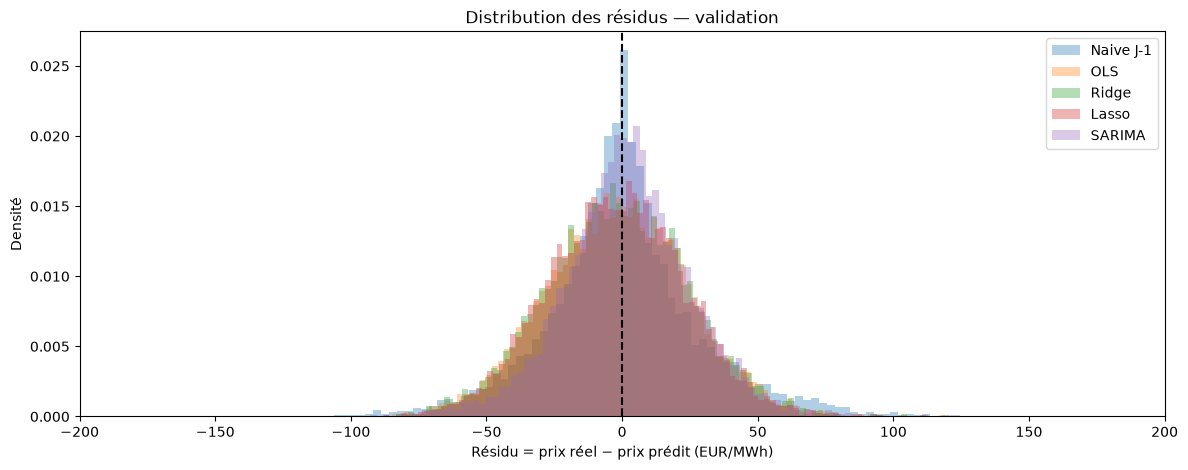

In [6]:
stat_predictions = pd.DataFrame(
    {
        "y_true": df[TARGET],
    },
    index=df.index,
)

stat_predictions.loc[
    ols_validation_pred.index, "OLS"
] = ols_validation_pred

stat_predictions.loc[
    ols_test_pred.index, "OLS"
] = ols_test_pred

stat_predictions.loc[
    ridge_validation_pred.index, "Ridge"
] = ridge_validation_pred

stat_predictions.loc[
    ridge_test_pred.index, "Ridge"
] = ridge_test_pred

stat_predictions.loc[
    lasso_validation_pred.index, "Lasso"
] = lasso_validation_pred

stat_predictions.loc[
    lasso_test_pred.index, "Lasso"
] = lasso_test_pred

stat_predictions.loc[
    sarima_validation_pred.index, "SARIMA"
] = sarima_validation_pred

stat_predictions.loc[
    sarima_test_pred.index, "SARIMA"
] = sarima_test_pred

# Baseline principale à battre
stat_predictions["Naive J-1"] = models.naive_persistence(
    df,
    price_col=TARGET,
    day_lag=1,
    timezone="Europe/Paris",
)

RESIDUAL_MODELS = [
    "Naive J-1",
    "OLS",
    "Ridge",
    "Lasso",
    "SARIMA",
]

residual_rows = []

for split_name, split_index in {
    "validation": validation_raw.index,
    "test": test_raw.index,
}.items():

    comparison = stat_predictions.loc[
        split_index,
        ["y_true"] + RESIDUAL_MODELS,
    ].dropna()

    for model_name in RESIDUAL_MODELS:
        residual = (
            comparison["y_true"]
            - comparison[model_name]
        )

        residual_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "mean": residual.mean(),
                "std": residual.std(),
                "median": residual.median(),
                "q05": residual.quantile(0.05),
                "q95": residual.quantile(0.95),
                "n_obs": len(residual),
            }
        )

residual_summary = pd.DataFrame(residual_rows)

display(
    residual_summary.style.format(
        {
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "median": "{:.2f}",
            "q05": "{:.2f}",
            "q95": "{:.2f}",
            "n_obs": "{:.0f}",
        }
    )
)

# Distribution des résidus de validation
validation_comparison = stat_predictions.loc[
    validation_raw.index,
    ["y_true"] + RESIDUAL_MODELS,
].dropna()

fig, ax = plt.subplots(figsize=(14, 5))

for model_name in RESIDUAL_MODELS:
    residual = (
        validation_comparison["y_true"]
        - validation_comparison[model_name]
    )

    ax.hist(
        residual,
        bins=100,
        density=True,
        alpha=0.35,
        label=model_name,
    )

ax.axvline(0, color="black", linestyle="--")
ax.set_xlim(-200, 200)
ax.set_title("Distribution des résidus — validation")
ax.set_xlabel("Résidu = prix réel − prix prédit (EUR/MWh)")
ax.set_ylabel("Densité")
ax.legend()
plt.show()

## Mise à jour du tableau de benchmark

In [7]:
# Reconstitution des trois baselines du notebook 06
hourly_means = models.fit_mean_by_hour(
    train_raw,
    price_col=TARGET,
    hour_col="hour",
)

stat_predictions["Moyenne horaire"] = (
    models.predict_mean_by_hour(
        df,
        hourly_means=hourly_means,
        hour_col="hour",
    )
)

stat_predictions["Naive J-7"] = models.naive_persistence(
    df,
    price_col=TARGET,
    day_lag=7,
    timezone="Europe/Paris",
)

BENCHMARK_MODELS = [
    "Moyenne horaire",
    "Naive J-1",
    "Naive J-7",
    "OLS",
    "Ridge",
    "Lasso",
    "SARIMA",
]

benchmark_rows = []

for split_name, split_index in {
    "validation": validation_raw.index,
    "test": test_raw.index,
}.items():

    evaluation = stat_predictions.loc[
        split_index,
        ["y_true"] + BENCHMARK_MODELS,
    ].dropna()

    print(
        split_name,
        ":",
        len(evaluation),
        "heures communes évaluées",
    )

    for model_name in BENCHMARK_MODELS:
        model_metrics = metrics.summary_metrics(
            evaluation["y_true"],
            evaluation[model_name],
        )

        benchmark_rows.append(
            {
                "split": split_name,
                "model": model_name,
                **model_metrics,
            }
        )

statistical_benchmark = pd.DataFrame(benchmark_rows)

statistical_benchmark = statistical_benchmark.sort_values(
    ["split", "RMSE"],
    ascending=[True, True],
).reset_index(drop=True)

display(
    statistical_benchmark.style.format(
        {
            "MAE": "{:.2f}",
            "RMSE": "{:.2f}",
            "sMAPE": "{:.2f}",
            "Bias": "{:.2f}",
            "n_obs": "{:.0f}",
        }
    )
)

validation : 8780 heures communes évaluées
test : 6548 heures communes évaluées


,split,model,MAE,RMSE,sMAPE,Bias,n_obs
0,test,SARIMA,19.78,26.14,61.00,0.50,6548
1,test,Lasso,22.45,28.67,64.53,-3.08,6548
2,test,Naive J-1,20.40,29.39,64.72,-0.14,6548
3,test,Ridge,23.03,29.42,65.82,-3.03,6548
4,test,OLS,23.08,29.53,66.06,-2.90,6548
5,test,Naive J-7,31.35,43.31,78.95,-1.37,6548
6,test,Moyenne horaire,125.82,134.67,112.85,-125.55,6548
7,validation,SARIMA,18.20,23.98,52.53,2.29,8780
8,validation,Lasso,20.31,25.52,56.05,-2.07,8780
9,validation,Ridge,21.04,26.46,57.62,-1.67,8780
